
--- PART 1: PERFORMANCE BENCHMARKING ---
Benchmarking Gradient Calculation on 100000 samples...
Running Loops on subset (1000 rows)...
Loop Time (1k rows): 1.18312 seconds
Running Vectorized on FULL dataset (100,000 rows)...
Vectorized Time (100k rows): 0.04566 seconds

--- PART 2: THE SCALING CRISIS (DIABETES DATASET) ---
Raw Data Stats:
Max per col: [1.10726675e-01 5.06801187e-02 1.70555226e+03 1.32043617e-01
 1.53913713e-01 1.98787990e-01 1.81179060e-01 1.85234443e-01
 1.33597282e+02 1.35611831e-01]
Min per col: [-1.07225632e-01 -4.46416365e-02 -9.02752959e+02 -1.12398803e-01
 -1.26780670e-01 -1.15613066e-01 -1.02307051e-01 -7.63945038e-02
 -1.26097121e+02 -1.37767226e-01]

Training on Unscaled Data (LR=0.01)...
Training diverged at epoch 42

--- PART 3: FIXING IT WITH STANDARDIZATION ---
Scaled Stats -> Mean: 0.0000, Std: 1.0000
Training on Scaled Data (LR=0.01)...
Training diverged at epoch 42


/tmp/ipython-input-2416897515.py:98: RuntimeWarning: overflow encountered in square
  loss = (1/m) * np.sum(errors**2)


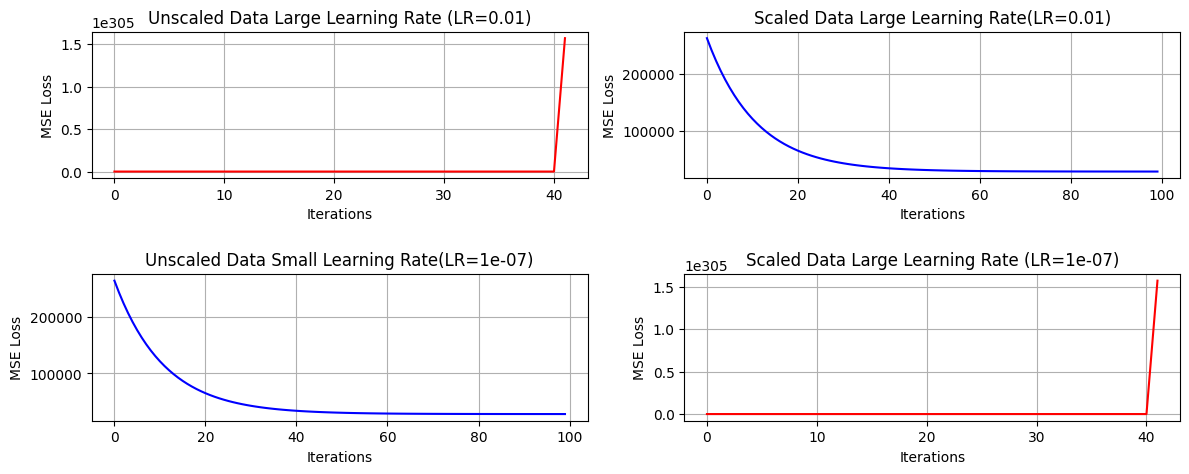


OBSERVATION:


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
import time

np.random.seed(42)

# =============================================================================
# PART 1: THE NEED FOR SPEED (LOOPS VS VECTORIZATION)
# =============================================================================
print("\n--- PART 1: PERFORMANCE BENCHMARKING ---")

N_big = 100_000
D_big = 50
X_big = np.random.rand(N_big, D_big)
y_big = np.random.rand(N_big, 1)
theta_big = np.random.rand(D_big + 1, 1)

X_big_b = np.c_[np.ones((N_big, 1)), X_big]

def gradient_loops(X, y, theta):
    """
    Calculate gradient using nested loops (Naive approach).
    """
    m, n = X.shape
    gradients = np.zeros((n, 1))

#mxn matrics .. m is the rows and n is the features
    for j in range(n):
        grad_sum = 0
        for i in range(m):
            prediction = 0
            for k in range(n):
                prediction += X[i, k] * theta[k, 0] #prediction for each theta/feature alone
            error = prediction - y[i, 0]
            grad_sum += error * X[i, j]
        gradients[j, 0] = (2 / m) * grad_sum

    return gradients

def gradient_vectorized(X, y, theta):
    """
    Calculate gradient using Matrix Algebra (The Industry Standard).
    """
    m = X.shape[0]
    return (2 / m) * X.T @ (X @ theta - y)

# --- BENCHMARKING With Subset ---
print(f"Benchmarking Gradient Calculation on {N_big} samples...")
#DOint it based on samples of 1k from the data
X_subset = X_big_b[:1000]
y_subset = y_big[:1000]
print("Running Loops on subset (1000 rows)...")
start = time.time()
grads_loop = gradient_loops(X_subset, y_subset, theta_big)
end = time.time()
print(f"Loop Time (1k rows): {end - start:.5f} seconds")

# 2. Time the Vectorized version (Full dataset)
print("Running Vectorized on FULL dataset (100,000 rows)...")
start = time.time()
grads_vec = gradient_vectorized(X_big_b, y_big, theta_big)
end = time.time()
print(f"Vectorized Time (100k rows): {end - start:.5f} seconds")


# =============================================================================
# PART 2: REAL WORLD DATA & THE SCALING PROBLEM
# =============================================================================
print("\n--- PART 2: THE SCALING CRISIS (DIABETES DATASET) ---")

data = load_diabetes()
X_real = data.data
y_real = data.target.reshape(-1, 1)

# SIMULATE RAW DATA:

X_raw = X_real.copy()
### Corrupt data with scalling BMI and Cerum Featuers
X_raw[:, 2] = X_raw[:, 2] * 10000
X_raw[:, 8] = X_raw[:, 8] * 1000

print(f"Raw Data Stats:\nMax per col: {np.max(X_raw, axis=0)}\nMin per col: {np.min(X_raw, axis=0)}")

m = len(y_real)
X_raw_b = np.c_[np.ones((m, 1)), X_raw]
theta_init = np.random.randn(X_raw_b.shape[1], 1)
EPOCHS=100

def train_model(X, y, theta_start, lr, epochs=EPOCHS):
    theta = theta_start.copy()
    loss_history = []
    steps = 0
    m = len(y)
    for i in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        loss = (1/m) * np.sum(errors**2)
        loss_history.append(loss)
        steps += 1
        if np.isnan(loss) or np.isinf(loss):
            print(f"Training diverged at epoch {i}")
            break
        gradients = (2/m) * X.T @ errors
        theta = theta - lr * gradients
    return theta, loss_history, steps

# EXPERIMENT A: TRAIN ON UNSCALED DATA

lr_unscaled_large = 0.01
print(f"\nTraining on Unscaled Data (LR={lr_unscaled_large})...")

lr_unscaled_small = 1e-7
theta_unscaled_bad, loss_unscaled_bad, _ = train_model(X_raw_b, y_real, theta_init, lr_unscaled_large)
theta_unscaled_good, loss_unscaled_good, _ = train_model(X_raw_b, y_real, theta_init, lr_unscaled_small)

# =============================================================================
# PART 3: FEATURE SCALING (Z-SCORE)
# =============================================================================
print("\n--- PART 3: FIXING IT WITH STANDARDIZATION ---")

def manual_standard_scaler(X):
    """
    Implement Z-score normalization: x' = (x - mean) / std
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled

# Scale the X_raw data
X_scaled = manual_standard_scaler(X_raw)

print(f"Scaled Stats -> Mean: {np.mean(X_scaled):.4f}, Std: {np.std(X_scaled):.4f}")

X_scaled_b = np.c_[np.ones((m, 1)), X_scaled]

# EXPERIMENT B: TRAIN ON SCALED DATA
lr_scaled_large = 0.01
lr_scaled_small = 1e-7

print(f"Training on Scaled Data (LR={lr_scaled_large})...")

theta_scaled_good, loss_scaled_good, _ = train_model(X_raw_b, y_real, theta_init, lr_scaled_small)
theta_scaled_bad, loss_scaled_bad, _ = train_model(X_raw_b, y_real, theta_init, lr_scaled_large)

# =============================================================================
# PART 4: VISUALIZATION & ANALYSIS
# =============================================================================
plt.figure(figsize=(12, 5))

# Plot 1: Unscaled large learning rate
plt.subplot(2, 2, 1)
if len(loss_unscaled_bad) > 0:
    plt.plot(loss_unscaled_bad, color='red')
plt.title(f"Unscaled Data Large Learning Rate (LR={lr_unscaled_large})")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.grid(True)

# Plot 2: Scaled large learning rate
plt.subplot(2, 2, 2)
if len(loss_scaled_good) > 0:
    plt.plot(loss_scaled_good, color='blue')
plt.title(f"Scaled Data Large Learning Rate(LR={lr_scaled_large})")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.grid(True)

# Plot 1: Unscaled small learning rate
plt.subplot(2, 2, 3)
if len(loss_unscaled_good) > 0:
    plt.plot(loss_unscaled_good, color='blue')
plt.title(f"Unscaled Data Small Learning Rate(LR={lr_unscaled_small})")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.grid(True)

# Plot 2: Scaled
plt.subplot(2, 2, 4)
if len(loss_scaled_bad) > 0:
    plt.plot(loss_scaled_bad, color='red')
plt.title(f"Scaled Data Large Learning Rate (LR={lr_scaled_small})")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nOBSERVATION:")

#if the learning rate is the same
#unscaled data forms an elipse bec the ranges of the features are very different
#so it never got to diverge in that epochs and learning rate
#if i increased the learning rate it may never converge bec it reaches minimum
#in a zig zag way so it may take thousands of epochs until it converges
#While the scaled data will form a circle making it reach min(converge)in a straight
#line which will converge faster

#if different learning rates are used on both they will converge
#but the unscaled will use learning rate very small like 10 to the power -7 will make it converge
#because since it is moving on large scales it will need to take fewer learning steps in order not to overlook the minimum
#and the opossite is applied to the scaled one
#scaled should move big steps since the data itself we know we'll be moving in a straight line to reach the minimum
